# Support Vector Machine implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **pandas** for tabular data handling, **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **load_breast_cancer** from scikit-learn as a real-data source.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

### Loading Data

Loads the real Breast Cancer Wisconsin dataset and selects two real features: **worst radius** and **worst concave points** as inputs. Converts the diagnosis into **+1/-1** labels rather than the usual **0/1**, since the SVM's math (checking whether **y × prediction** is positive or negative) only works correctly with signed labels.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

y_raw = (1 - df["target"].values)          # 1 = malignant, 0 = benign
y_train = np.where(y_raw == 1, 1, -1)      # SVM requires labels in {-1, +1}, not {0, 1}
X_train = df[["worst radius", "worst concave points"]].values

print(f"Examples: {X_train.shape[0]}")
print(f"Class balance: {(y_train == 1).sum()} malignant, {(y_train == -1).sum()} benign")

Examples: 569
Class balance: 212 malignant, 357 benign


### Standardizing Features

Scales both features to the same standardized range.

In [3]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_scaled = (X_train - X_mean) / X_std

### Visualization

Plots the two real classes against each other on the two standardized features, to see how separable they are before fitting anything.

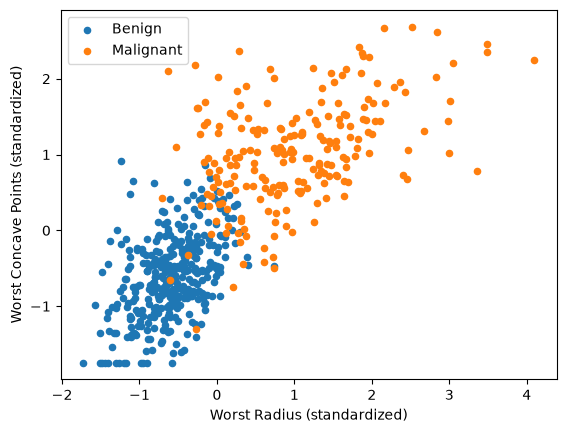

In [4]:
plt.scatter(X_train_scaled[y_train == -1, 0], X_train_scaled[y_train == -1, 1],
            color='tab:blue', label='Benign', s=20)
plt.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1],
            color='tab:orange', label='Malignant', s=20)
plt.xlabel('Worst Radius (standardized)')
plt.ylabel('Worst Concave Points (standardized)')
plt.legend()
plt.show()

Shows real, largely separable clusters with malignant tumors trending toward higher values of both features.

### SVM Class

Implements a linear support vector machine from scratch. Rather than minimizing prediction error directly (like logistic regression), it searches for the decision boundary with the widest possible margin between the two classes. For each real training point, it checks whether that point already satisfies the margin condition (**y × (w·x + b) ≥ 1**); if so, only a small regularization pull is applied to **w**. If not, the point is inside the margin or misclassified, and a stronger correction scaled by the **C** parameter pulls the boundary toward classifying it correctly. This is hinge loss, optimized here via subgradient descent (updating from one real training point at a time).

In [5]:
class SVM:
    def __init__(self, C=5.0, learning_rate=0.001, iterations=1000):
        self.C = C
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for it in range(self.iterations):
            for i in range(m):
                margin_satisfied = y[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if margin_satisfied:
                    dw = self.w
                    db = 0
                else:
                    dw = self.w - self.C * y[i] * X[i]
                    db = -self.C * y[i]

                self.w = self.w - self.learning_rate * dw
                self.b = self.b - self.learning_rate * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

### Training Model

Fits the SVM on the real standardized data with **C=5.0**.

In [6]:
svm = SVM(C=5.0, learning_rate=0.001, iterations=1000)
svm.fit(X_train_scaled, y_train)

predictions = svm.predict(X_train_scaled)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training accuracy: {accuracy:.2f}%")
print(f"w: {svm.w}, b: {svm.b:.4f}")

Training accuracy: 93.32%
w: [0.66184603 0.67588496], b: -0.5400


**93.32% training accuracy**, converging to **w = [0.662, 0.676], b = -0.540**.

### Visualizing the Decision Boundary

Plots not just the decision boundary itself, but the two margin lines on either side of it.

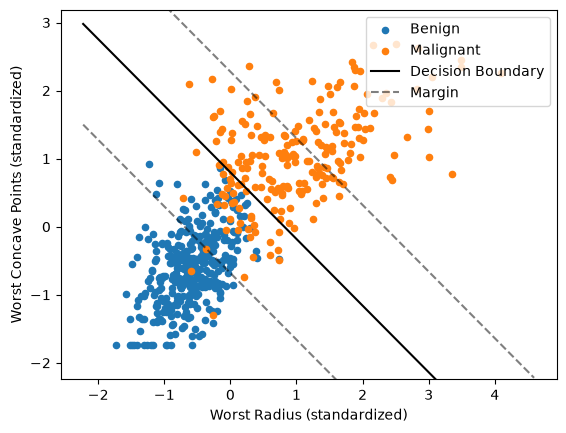

In [7]:
w0, w1 = svm.w
xmin, xmax = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
xd = np.linspace(xmin, xmax, 100)

# w0*x + w1*y + b = 0  -> the decision boundary itself
decision_boundary = -(w0 * xd + svm.b) / w1
# w0*x + w1*y + b = ±1 -> the two margin lines on either side
margin_pos = -(w0 * xd + svm.b - 1) / w1
margin_neg = -(w0 * xd + svm.b + 1) / w1

plt.scatter(X_train_scaled[y_train == -1, 0], X_train_scaled[y_train == -1, 1],
            color='tab:blue', label='Benign', s=20)
plt.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1],
            color='tab:orange', label='Malignant', s=20)

plt.plot(xd, decision_boundary, 'k-', label='Decision Boundary')
plt.plot(xd, margin_pos, 'k--', alpha=0.5, label='Margin')
plt.plot(xd, margin_neg, 'k--', alpha=0.5)

plt.xlabel('Worst Radius (standardized)')
plt.ylabel('Worst Concave Points (standardized)')
plt.ylim(X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5)
plt.legend()
plt.show()

The solid decision boundary runs through the region separating the two real classes, with the dashed margin lines showing how much buffer space the model found on either side.

### Sklearn Validation

Fits scikit-learn's **SVC** with a linear kernel and the same **C=5.0** on the identical data, as an independent correctness check.

In [8]:
from sklearn.svm import SVC

sk_svm = SVC(kernel='linear', C=5.0)
sk_svm.fit(X_train_scaled, y_train)
sk_accuracy = sk_svm.score(X_train_scaled, y_train) * 100

print(f"From scratch: {accuracy:.2f}%")
print(f"sklearn:      {sk_accuracy:.2f}%")

From scratch: 93.32%
sklearn:      94.55%


93.32% (from scratch) vs. 94.55% (sklearn)